# 8 — Representative Propeller Selection

**Author:** Héctor Fernández Pinacho**  
**Project:** IDEAL Lab Bachelor Thesis — Propeller Dataset Pipeline

---

## Purpose

This notebook selects a small set of representative propellers from the full generated dataset.

The goal is not to simulate new physics. The goal is to choose configurations that are useful for inspection, printing, validation, and later comparison against the full pipeline.

The notebook combines:

- geometric parameters,
- mass estimates,
- QPROP aerodynamic results,
- vertical flight-dynamics results,
- optional NACA code information.

It then selects representative configurations using a reproducible clustering method and also reports a few special configurations that are useful for engineering sanity checks.

---

## Main outputs

The notebook writes:

- `./csv/representative_propellers.csv`
- `./csv/representative_geometry.csv`
- `./csv/representative_special_cases.csv`

The first file contains all available data for the selected representative configurations.  
The second file contains only the geometry parameters needed by the geometry-generation pipeline.  
The third file contains hand-picked special cases such as the thinnest propeller and the most average performance propeller.

## 1. Imports and constants

All paths, feature lists, and selection parameters are defined here.

This makes the notebook easy to adapt if the previous notebooks change their output names or if the number of representative propellers needs to be changed.

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


warnings.filterwarnings("ignore")


# -----------------------------
# Project paths
# -----------------------------

PROJECT_DIR = Path.cwd()
CSV_DIR = PROJECT_DIR / "csv"

GEOMETRY_CSV_PATH = CSV_DIR / "prop_geometrical_params.csv"
MASS_CSV_PATH = CSV_DIR / "prop_mass_estimation.csv"
NACA_CSV_PATH = CSV_DIR / "naca_codes.csv"
QPROP_RESULTS_CSV_PATH = CSV_DIR / "qprop_batch_results.csv"
FLIGHT_DYNAMICS_CSV_PATH = CSV_DIR / "flight_dynamics.csv"

REPRESENTATIVE_OUTPUT_PATH = CSV_DIR / "representative_propellers.csv"
REPRESENTATIVE_GEOMETRY_OUTPUT_PATH = CSV_DIR / "representative_geometry.csv"
SPECIAL_CASES_OUTPUT_PATH = CSV_DIR / "representative_special_cases.csv"


# -----------------------------
# Selection setup
# -----------------------------

N_REPRESENTATIVE_PROPELLERS = 100
RANDOM_SEED = 42

# If True, only configurations that can lift off are considered for the main
# representative set. If False, the representative set covers the whole dataset.
FILTER_MAIN_SELECTION_TO_LIFTOFF_CONFIGS = False

# K-means settings.
KMEANS_N_INIT = 30
KMEANS_MAX_ITER = 600


# -----------------------------
# Geometry constants
# -----------------------------

INNER_PROFILE_RADIUS_MM = 4.5
HUB_OUTER_RADIUS_MM = 8.25

# For root-section solidity, the physically active section starts at the hub.
# The hidden inner profile can still be part of CAD loft construction, but the
# aerodynamic root section starts at the hub outer radius.
INNER_SOLIDITY_RADIUS_MM = HUB_OUTER_RADIUS_MM


# -----------------------------
# Candidate features
# -----------------------------

# Features used for the main K-means selection.
# The code will automatically keep only the columns that are available.
CLUSTER_FEATURE_CANDIDATES = [
    # Geometry
    "radius",
    "ring height",
    "ring thickness",
    "blade count",
    "inner thickness",
    "inner max pos",
    "inner camber",
    "inner chord",
    "inner angle",
    "mid radial pos",
    "mid chord",
    "mid angle",
    "outer thickness",
    "outer max pos",
    "outer camber",
    "outer chord",
    "outer angle",

    # Derived geometry
    "inner_solidity",
    "mid_solidity",
    "min_blade_abs_thickness_mm",

    # Mass
    "m_hub_kg",
    "m_blades_kg",
    "m_outer_ring_kg",
    "m_total_kg",

    # QPROP
    "T",
    "Pshaft",
    "Q",
    "CT",
    "CP",
    "FOM",
    "eff_aero",
    "cl_avg",
    "cd_avg",

    # Flight dynamics
    "T_static_N",
    "Pshaft_ref_W",
    "T_over_W_static",
    "h_max_m",
    "flight_time_s",
    "hover_time_s",
    "v_max_up_m_s",
    "v_impact_m_s",
    "spin_stop_time_s",
]

# Features used to define the most average propeller in terms of performance.
# These should be performance outputs, not pure geometry.
AVERAGE_PERFORMANCE_FEATURE_CANDIDATES = [
    "T_over_W_static",
    "h_max_m",
    "flight_time_s",
    "hover_time_s",
    "v_max_up_m_s",
    "T",
    "Pshaft",
    "FOM",
    "eff_aero",
]


# -----------------------------
# Geometry-only export schema
# -----------------------------

GEOMETRY_EXPORT_COLUMNS = [
    "config_id",
    "radius",
    "ring height",
    "ring thickness",
    "blade count",
    "inner thickness",
    "inner max pos",
    "inner camber",
    "inner chord",
    "inner angle",
    "mid radial pos",
    "mid chord",
    "mid angle",
    "outer thickness",
    "outer max pos",
    "outer camber",
    "outer chord",
    "outer angle",
]


# -----------------------------
# Output formatting
# -----------------------------

ROUND_OUTPUT_DECIMALS = 6

print(f"Geometry CSV          : {GEOMETRY_CSV_PATH}")
print(f"Mass CSV              : {MASS_CSV_PATH}")
print(f"NACA CSV              : {NACA_CSV_PATH}")
print(f"QPROP results CSV     : {QPROP_RESULTS_CSV_PATH}")
print(f"Flight dynamics CSV   : {FLIGHT_DYNAMICS_CSV_PATH}")
print(f"Representative output : {REPRESENTATIVE_OUTPUT_PATH}")
print(f"Special cases output  : {SPECIAL_CASES_OUTPUT_PATH}")

Geometry CSV          : c:\Users\hecto\Desktop\bachelor-thesis\IDEAL-Propeller-Dataset\csv\prop_geometrical_params.csv
Mass CSV              : c:\Users\hecto\Desktop\bachelor-thesis\IDEAL-Propeller-Dataset\csv\prop_mass_estimation.csv
NACA CSV              : c:\Users\hecto\Desktop\bachelor-thesis\IDEAL-Propeller-Dataset\csv\naca_codes.csv
QPROP results CSV     : c:\Users\hecto\Desktop\bachelor-thesis\IDEAL-Propeller-Dataset\csv\qprop_batch_results.csv
Flight dynamics CSV   : c:\Users\hecto\Desktop\bachelor-thesis\IDEAL-Propeller-Dataset\csv\flight_dynamics.csv
Representative output : c:\Users\hecto\Desktop\bachelor-thesis\IDEAL-Propeller-Dataset\csv\representative_propellers.csv
Special cases output  : c:\Users\hecto\Desktop\bachelor-thesis\IDEAL-Propeller-Dataset\csv\representative_special_cases.csv


## 2. Load and merge pipeline outputs

The previous pipeline notebooks write one row per `config_id`.  
This notebook keeps `config_id` as the master key so that geometry, mass, aerodynamic, and flight-performance results remain aligned.

If one optional file is missing, the notebook still runs with the available data. This is useful during development, because the representative-selection logic can be tested before the full simulation pipeline has finished.

In [2]:
def read_csv_if_exists(path, dtype=None, required=False):
    """Read a CSV if it exists. Return an empty DataFrame when optional files are missing."""
    if not path.exists():
        if required:
            raise FileNotFoundError(f"Required file not found: {path}")
        print(f"[WARN] Optional file not found: {path}")
        return pd.DataFrame()
    return pd.read_csv(path, dtype=dtype)


def ensure_config_id(df, reference_config_ids=None, name="dataframe"):
    """
    Ensure that a DataFrame has config_id.

    Some intermediate files may have been produced by older versions of the
    pipeline. If config_id is missing but the row count matches the geometry
    file, the ids are copied from the geometry table.
    """
    if df.empty:
        return df

    if "config_id" in df.columns:
        df = df.copy()
        df["config_id"] = df["config_id"].astype(int)
        return df

    if reference_config_ids is not None and len(reference_config_ids) == len(df):
        df = df.copy()
        df.insert(0, "config_id", reference_config_ids.astype(int).to_numpy())
        print(f"[WARN] Added config_id to {name} using geometry row order.")
        return df

    raise ValueError(
        f"{name} does not contain config_id and cannot be aligned safely."
    )


geometry_df = read_csv_if_exists(GEOMETRY_CSV_PATH, required=True)
geometry_df = ensure_config_id(geometry_df, name="geometry_df")
geometry_df = geometry_df.sort_values("config_id").reset_index(drop=True)

reference_ids = geometry_df["config_id"]

mass_df = read_csv_if_exists(MASS_CSV_PATH)
mass_df = ensure_config_id(mass_df, reference_ids, name="mass_df")

naca_df = read_csv_if_exists(
    NACA_CSV_PATH,
    dtype={
        "naca_hub": str,
        "naca_inner": str,
        "naca_mid": str,
        "naca_outer": str,
    },
)
naca_df = ensure_config_id(naca_df, reference_ids, name="naca_df")

qprop_df = read_csv_if_exists(QPROP_RESULTS_CSV_PATH)
qprop_df = ensure_config_id(qprop_df, reference_ids, name="qprop_df")

flight_df = read_csv_if_exists(FLIGHT_DYNAMICS_CSV_PATH)
flight_df = ensure_config_id(flight_df, reference_ids, name="flight_df")


# If QPROP contains several rows per configuration, reduce it to one row.
# Prefer V = 0 when present because this is the reference launch condition.
if not qprop_df.empty:
    if "V" in qprop_df.columns:
        qprop_df = qprop_df.sort_values(["config_id", "V"]).copy()
        qprop_zero = qprop_df[np.isclose(qprop_df["V"], 0.0)]
        if not qprop_zero.empty:
            qprop_df = qprop_zero.drop_duplicates("config_id", keep="first")
        else:
            qprop_df = qprop_df.drop_duplicates("config_id", keep="first")
    else:
        qprop_df = qprop_df.drop_duplicates("config_id", keep="first")


merged_df = geometry_df.copy()

for optional_df, label in [
    (mass_df, "mass"),
    (naca_df, "naca"),
    (qprop_df, "qprop"),
    (flight_df, "flight"),
]:
    if not optional_df.empty:
        before_cols = set(merged_df.columns)
        merged_df = merged_df.merge(optional_df, on="config_id", how="left", suffixes=("", f"_{label}"))
        added_cols = [col for col in merged_df.columns if col not in before_cols]
        print(f"Merged {label:<6}: added {len(added_cols)} columns")


merged_df = merged_df.sort_values("config_id").reset_index(drop=True)

print()
print(f"Merged dataset rows    : {len(merged_df)}")
print(f"Merged dataset columns : {len(merged_df.columns)}")
merged_df.head()

Merged mass  : added 4 columns
Merged naca  : added 4 columns
Merged qprop : added 13 columns
Merged flight: added 17 columns

Merged dataset rows    : 5000
Merged dataset columns : 56


,config_id,radius,ring height,ring thickness,blade count,inner thickness,inner max pos,inner camber,inner chord,inner angle,...,Pshaft_ref_W,Q_ref_Nm,T_over_W_static,h_max_m,flight_time_s,hover_time_s,v_max_up_m_s,v_impact_m_s,rpm_impact,spin_stop_time_s
0,0,67,5,2,5,17,6,4,7,23,...,1.091180,0.002605,2.440980,19.220549,7.373207,2.203346,7.526460,-9.284935,1388.073307,NaN
1,1,60,4,1,3,19,5,6,11,25,...,0.813882,0.001943,3.654536,16.300632,5.853053,1.563420,8.709653,-9.100018,908.114468,NaN
2,2,80,10,4,5,18,5,5,6,17,...,4.737522,0.011310,3.275580,37.436255,10.466123,3.214969,11.817087,-10.522479,1103.687335,NaN
3,3,66,9,1,6,22,4,7,5,22,...,1.442619,0.003444,4.786902,31.757538,8.381763,2.308833,13.412386,-10.647001,753.173453,NaN
4,4,67,9,2,5,18,4,8,6,22,...,0.455321,0.001087,1.013896,0.000945,0.307488,0.101640,0.006926,-0.020636,3918.186865,NaN


## 3. Derived geometry metrics

Several representative cases are easier to identify from derived geometric quantities than from raw slider values.

### Solidity

The local solidity is approximated as:

$$
\sigma(r)=\frac{N_b c(r)}{2\pi r}
$$

where:

- $N_b$ is the blade count,
- $c(r)$ is the local chord,
- $r$ is the local radial position.

For the inner/root section, the radius used is the **hub outer radius** because the hidden inner profile is mainly a loft-control profile and is not the exposed aerodynamic root of the free propeller.

### Minimum printable blade thickness

The local absolute thickness is approximated as:

$$
t_\mathrm{abs}(r)=c(r)\frac{t_\% (r)}{100}
$$

The thinnest propeller is identified using the smallest value across the inner, mid, and outer sections.

In [3]:
def add_derived_geometry_metrics(df):
    """Add solidity and absolute-thickness metrics used for selection and special cases."""
    df = df.copy()

    blade_count = df["blade count"].astype(float)

    df["inner_solidity"] = (
        blade_count * df["inner chord"].astype(float)
        / (2.0 * np.pi * INNER_SOLIDITY_RADIUS_MM)
    )

    mid_radius_mm = df["radius"].astype(float) * df["mid radial pos"].astype(float)
    df["mid_radius_mm"] = mid_radius_mm

    df["mid_solidity"] = (
        blade_count * df["mid chord"].astype(float)
        / (2.0 * np.pi * mid_radius_mm)
    )

    # The generator does not expose a separate mid-thickness slider.
    # The mid thickness is reconstructed from the inner and outer thicknesses
    # at the normalized mid radial position.
    df["mid_thickness"] = (
        df["inner thickness"].astype(float)
        + df["mid radial pos"].astype(float)
        * (df["outer thickness"].astype(float) - df["inner thickness"].astype(float))
    )

    df["inner_abs_thickness_mm"] = (
        df["inner chord"].astype(float) * df["inner thickness"].astype(float) / 100.0
    )

    df["mid_abs_thickness_mm"] = (
        df["mid chord"].astype(float) * df["mid_thickness"].astype(float) / 100.0
    )

    df["outer_abs_thickness_mm"] = (
        df["outer chord"].astype(float) * df["outer thickness"].astype(float) / 100.0
    )

    thickness_cols = [
        "inner_abs_thickness_mm",
        "mid_abs_thickness_mm",
        "outer_abs_thickness_mm",
    ]

    df["min_blade_abs_thickness_mm"] = df[thickness_cols].min(axis=1)
    df["max_section_solidity"] = df[["inner_solidity", "mid_solidity"]].max(axis=1)

    return df


analysis_df = add_derived_geometry_metrics(merged_df)

derived_cols = [
    "config_id",
    "inner_solidity",
    "mid_solidity",
    "mid_radius_mm",
    "inner_abs_thickness_mm",
    "mid_abs_thickness_mm",
    "outer_abs_thickness_mm",
    "min_blade_abs_thickness_mm",
]

analysis_df[derived_cols].head()

,config_id,inner_solidity,mid_solidity,mid_radius_mm,inner_abs_thickness_mm,mid_abs_thickness_mm,outer_abs_thickness_mm,min_blade_abs_thickness_mm
0,0,0.675203,0.522598,33.5,1.19,3.190,1.44,1.19
1,1,0.636620,0.225470,36.0,2.09,2.720,2.24,2.09
2,2,0.578745,0.571963,32.0,1.08,3.496,1.98,1.08
3,3,0.578745,0.347247,33.0,1.10,2.100,1.30,1.10
4,4,0.578745,0.623555,26.8,1.08,3.696,2.55,1.08


## 4. Representative set using K-means

The main representative set is selected by clustering the dataset in a combined geometry-performance space.

The procedure is:

1. keep only available feature columns;
2. remove rows with missing values in those features;
3. standardize all features;
4. run K-means with one cluster per desired representative propeller;
5. select the configuration closest to each cluster centroid.

This gives a set that is spread across the design space and is not simply the top-performing configurations.

In [4]:
def choose_available_features(df, candidates):
    """Return candidate features that are present and contain at least one non-null value."""
    available = []
    missing = []

    for col in candidates:
        if col in df.columns and df[col].notna().any():
            available.append(col)
        else:
            missing.append(col)

    return available, missing


def select_representative_configs(df, feature_candidates, n_select):
    """Select representative configurations using standardized K-means clustering."""
    if FILTER_MAIN_SELECTION_TO_LIFTOFF_CONFIGS and "can_liftoff" in df.columns:
        pool_df = df[df["can_liftoff"].fillna(False).astype(bool)].copy()
    else:
        pool_df = df.copy()

    features, missing_features = choose_available_features(pool_df, feature_candidates)

    if len(features) < 2:
        raise ValueError(
            "Not enough available features for representative selection. "
            f"Available features: {features}"
        )

    feature_df = pool_df[["config_id"] + features].dropna().copy()

    if feature_df.empty:
        raise ValueError("No rows left after dropping missing feature values.")

    n_clusters = min(int(n_select), len(feature_df))

    scaler = StandardScaler()
    X = scaler.fit_transform(feature_df[features].astype(float))

    kmeans = KMeans(
        n_clusters=n_clusters,
        random_state=RANDOM_SEED,
        n_init=KMEANS_N_INIT,
        max_iter=KMEANS_MAX_ITER,
    )

    labels = kmeans.fit_predict(X)
    feature_df["cluster"] = labels

    selected_config_ids = []
    cluster_sizes = []

    for cluster_id in range(n_clusters):
        member_mask = labels == cluster_id
        member_positions = np.where(member_mask)[0]
        member_X = X[member_positions]

        centroid = kmeans.cluster_centers_[cluster_id]
        distances = np.linalg.norm(member_X - centroid, axis=1)

        best_position = member_positions[int(np.argmin(distances))]
        selected_config_ids.append(int(feature_df.iloc[best_position]["config_id"]))
        cluster_sizes.append(int(member_mask.sum()))

    selected_df = (
        df[df["config_id"].isin(selected_config_ids)]
        .copy()
        .sort_values("config_id")
        .reset_index(drop=True)
    )

    diagnostics = {
        "features": features,
        "missing_features": missing_features,
        "n_valid_rows": len(feature_df),
        "n_clusters": n_clusters,
        "inertia": float(kmeans.inertia_),
        "cluster_sizes": cluster_sizes,
        "scaler": scaler,
        "kmeans": kmeans,
        "X": X,
        "feature_df": feature_df,
    }

    return selected_df, diagnostics


representative_df, selection_info = select_representative_configs(
    analysis_df,
    CLUSTER_FEATURE_CANDIDATES,
    N_REPRESENTATIVE_PROPELLERS,
)

print(f"Selected configurations : {len(representative_df)}")
print(f"Valid clustering rows   : {selection_info['n_valid_rows']}")
print(f"Features used           : {len(selection_info['features'])}")
print(f"K-means inertia         : {selection_info['inertia']:.3f}")
print()
print("Feature list:")
for feature in selection_info["features"]:
    print(f"  - {feature}")

if selection_info["missing_features"]:
    print()
    print("Skipped missing features:")
    for feature in selection_info["missing_features"]:
        print(f"  - {feature}")

representative_df.head()

Selected configurations : 100
Valid clustering rows   : 4289
Features used           : 41
K-means inertia         : 69814.295

Feature list:
  - radius
  - ring height
  - ring thickness
  - blade count
  - inner thickness
  - inner max pos
  - inner camber
  - inner chord
  - inner angle
  - mid radial pos
  - mid chord
  - mid angle
  - outer thickness
  - outer max pos
  - outer camber
  - outer chord
  - outer angle
  - inner_solidity
  - mid_solidity
  - min_blade_abs_thickness_mm
  - m_hub_kg
  - m_blades_kg
  - m_outer_ring_kg
  - m_total_kg
  - T
  - Pshaft
  - Q
  - CT
  - CP
  - FOM
  - eff_aero
  - cl_avg
  - cd_avg
  - T_static_N
  - Pshaft_ref_W
  - T_over_W_static
  - h_max_m
  - flight_time_s
  - hover_time_s
  - v_max_up_m_s
  - v_impact_m_s

Skipped missing features:
  - spin_stop_time_s


,config_id,radius,ring height,ring thickness,blade count,inner thickness,inner max pos,inner camber,inner chord,inner angle,...,spin_stop_time_s,inner_solidity,mid_radius_mm,mid_solidity,mid_thickness,inner_abs_thickness_mm,mid_abs_thickness_mm,outer_abs_thickness_mm,min_blade_abs_thickness_mm,max_section_solidity
0,132,75,9,3,5,22,4,4,6,21,...,NaN,0.578745,37.5,0.594178,16.5,1.32,4.62,1.98,1.32,0.594178
1,156,66,6,2,4,21,5,6,5,23,...,NaN,0.385830,33.0,0.231498,16.5,1.05,1.98,1.20,1.05,0.385830
2,168,64,8,2,5,20,5,6,5,22,...,NaN,0.482288,32.0,0.497359,14.5,1.00,2.90,1.08,1.00,0.497359
3,192,69,6,3,5,23,4,5,6,22,...,NaN,0.578745,41.4,0.480540,21.8,1.38,5.45,2.52,1.38,0.578745
4,299,76,5,2,4,16,4,5,8,18,...,NaN,0.617328,38.0,0.301557,13.0,1.28,2.34,1.80,1.28,0.617328


## 5. Special representative configurations

The K-means set is useful for broad coverage, but some individual designs are important for engineering interpretation.

This section identifies:

1. **Thinnest propeller** — smallest minimum absolute blade thickness.
2. **Most solid inner/root section** — largest root solidity.
3. **Most solid mid section** — largest mid solidity.
4. **Most average performance propeller** — closest to the mean of the available performance metrics.

The most average performance configuration is computed in standardized performance space. This prevents one metric from dominating only because it has larger numerical units.

In [5]:
def get_row_by_idx(df, idx, label, reason):
    """Build a compact one-row summary for a special representative case."""
    row = df.loc[idx].copy()

    summary = {
        "case": label,
        "reason": reason,
        "config_id": int(row["config_id"]),
    }

    display_columns = [
        "radius",
        "blade count",
        "m_total_kg",
        "inner_solidity",
        "mid_solidity",
        "min_blade_abs_thickness_mm",
        "T_over_W_static",
        "h_max_m",
        "flight_time_s",
        "hover_time_s",
        "v_max_up_m_s",
        "T",
        "Pshaft",
        "FOM",
    ]

    for col in display_columns:
        if col in df.columns:
            summary[col] = row[col]

    return summary


special_rows = []

# 1. Thinnest propeller.
idx_thinnest = analysis_df["min_blade_abs_thickness_mm"].idxmin()
special_rows.append(
    get_row_by_idx(
        analysis_df,
        idx_thinnest,
        "thinnest_propeller",
        "Minimum absolute blade thickness across inner, mid, and outer sections.",
    )
)

# 2. Most solid inner/root section.
idx_inner_solid = analysis_df["inner_solidity"].idxmax()
special_rows.append(
    get_row_by_idx(
        analysis_df,
        idx_inner_solid,
        "most_solid_inner_section",
        "Maximum root-section solidity using the hub outer radius.",
    )
)

# 3. Most solid mid section.
idx_mid_solid = analysis_df["mid_solidity"].idxmax()
special_rows.append(
    get_row_by_idx(
        analysis_df,
        idx_mid_solid,
        "most_solid_mid_section",
        "Maximum mid-section solidity.",
    )
)

# 4. Most average performance.
average_features, missing_average_features = choose_available_features(
    analysis_df,
    AVERAGE_PERFORMANCE_FEATURE_CANDIDATES,
)

average_feature_df = analysis_df[["config_id"] + average_features].dropna().copy()

if len(average_features) >= 2 and not average_feature_df.empty:
    scaler_average = StandardScaler()
    X_average = scaler_average.fit_transform(average_feature_df[average_features].astype(float))

    mean_point = np.zeros(len(average_features))
    distances_to_average = np.linalg.norm(X_average - mean_point, axis=1)

    best_average_row_position = int(np.argmin(distances_to_average))
    best_average_config_id = int(average_feature_df.iloc[best_average_row_position]["config_id"])

    idx_average = analysis_df.index[analysis_df["config_id"] == best_average_config_id][0]

    special_rows.append(
        get_row_by_idx(
            analysis_df,
            idx_average,
            "most_average_performance",
            "Smallest standardized distance to the mean of the available performance metrics.",
        )
    )

    print("Average-performance features used:")
    for feature in average_features:
        print(f"  - {feature}")
else:
    print("[WARN] Not enough performance columns available to compute most_average_performance.")

special_cases_df = pd.DataFrame(special_rows)

# Keep compact and readable numeric output.
numeric_cols = special_cases_df.select_dtypes(include=[np.number]).columns
special_cases_df[numeric_cols] = special_cases_df[numeric_cols].round(ROUND_OUTPUT_DECIMALS)

special_cases_df

Average-performance features used:
  - T_over_W_static
  - h_max_m
  - flight_time_s
  - hover_time_s
  - v_max_up_m_s
  - T
  - Pshaft
  - FOM
  - eff_aero


,case,reason,config_id,radius,blade count,m_total_kg,inner_solidity,mid_solidity,min_blade_abs_thickness_mm,T_over_W_static,h_max_m,flight_time_s,hover_time_s,v_max_up_m_s,T,Pshaft,FOM
0,thinnest_propeller,"Minimum absolute blade thickness across inner,...",43,64,5,0.006905,0.675203,0.227956,1.00,0.542710,0.000000,0.000000,0.000000,0.000000,0.03676,0.3165,0.12542
1,most_solid_inner_section,Maximum root-section solidity using the hub ou...,10,64,6,0.009564,0.694494,0.447623,1.20,2.152016,6.078548,3.878433,1.048925,4.073288,0.20190,1.8640,0.27411
2,most_solid_mid_section,Maximum mid-section solidity.,794,60,6,0.017086,0.578745,0.848826,1.20,1.319673,2.353037,3.612311,1.103594,1.534155,0.22120,0.7909,0.79022
3,most_average_performance,Smallest standardized distance to the mean of ...,3011,69,6,0.011778,0.694494,0.726577,1.14,1.775957,5.604284,4.065781,1.126744,3.403440,0.20520,1.3180,0.36842


## 6. Coverage visualization

The plot below projects the clustering features onto two principal components.

This is only a visualization; the actual selection is performed in the full standardized feature space.  
A good representative set should cover the point cloud rather than only selecting from one narrow region.

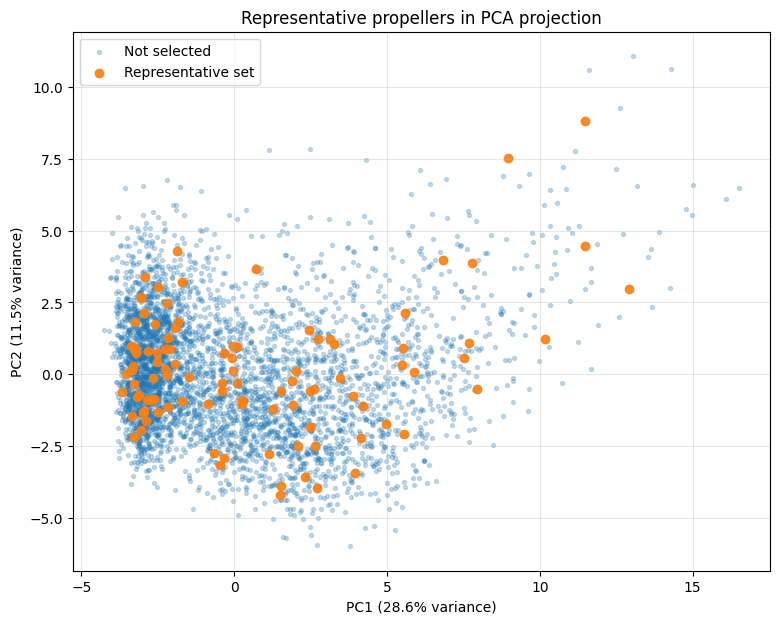

In [6]:
feature_df = selection_info["feature_df"]
X = selection_info["X"]

pca = PCA(n_components=2, random_state=RANDOM_SEED)
X_pca = pca.fit_transform(X)

plot_df = feature_df[["config_id"]].copy()
plot_df["PC1"] = X_pca[:, 0]
plot_df["PC2"] = X_pca[:, 1]
plot_df["selected"] = plot_df["config_id"].isin(representative_df["config_id"])

plt.figure(figsize=(9, 7))
plt.scatter(
    plot_df.loc[~plot_df["selected"], "PC1"],
    plot_df.loc[~plot_df["selected"], "PC2"],
    s=8,
    alpha=0.25,
    label="Not selected",
)

plt.scatter(
    plot_df.loc[plot_df["selected"], "PC1"],
    plot_df.loc[plot_df["selected"], "PC2"],
    s=36,
    alpha=0.9,
    label="Representative set",
)

plt.xlabel(f"PC1 ({100 * pca.explained_variance_ratio_[0]:.1f}% variance)")
plt.ylabel(f"PC2 ({100 * pca.explained_variance_ratio_[1]:.1f}% variance)")
plt.title("Representative propellers in PCA projection")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 7. Summary tables

This section compares the selected representative set against the full available dataset.

The purpose is to quickly check whether the selected set has a reasonable spread in geometry, mass, and performance.

In [7]:
SUMMARY_COLUMNS = [
    "radius",
    "blade count",
    "m_total_kg",
    "inner_solidity",
    "mid_solidity",
    "min_blade_abs_thickness_mm",
    "T_over_W_static",
    "h_max_m",
    "flight_time_s",
    "hover_time_s",
    "v_max_up_m_s",
    "T",
    "Pshaft",
    "FOM",
]

summary_rows = []

for col in SUMMARY_COLUMNS:
    if col not in analysis_df.columns:
        continue

    full_series = analysis_df[col].dropna()
    selected_series = representative_df[col].dropna()

    if full_series.empty or selected_series.empty:
        continue

    summary_rows.append(
        {
            "metric": col,
            "full_mean": full_series.mean(),
            "full_std": full_series.std(),
            "full_min": full_series.min(),
            "full_max": full_series.max(),
            "selected_mean": selected_series.mean(),
            "selected_std": selected_series.std(),
            "selected_min": selected_series.min(),
            "selected_max": selected_series.max(),
        }
    )

summary_df = pd.DataFrame(summary_rows)

numeric_cols = summary_df.select_dtypes(include=[np.number]).columns
summary_df[numeric_cols] = summary_df[numeric_cols].round(ROUND_OUTPUT_DECIMALS)

summary_df

,metric,full_mean,full_std,full_min,full_max,selected_mean,selected_std,selected_min,selected_max
0,radius,70.000000,5.788497,60.000000,80.000000,69.660000,5.358313,61.000000,80.000000
1,blade count,4.500000,0.957384,3.000000,6.000000,4.570000,0.794616,3.000000,6.000000
2,m_total_kg,0.013074,0.005509,0.003226,0.040531,0.013086,0.004910,0.004767,0.026274
3,inner_solidity,0.556232,0.097992,0.289373,0.694494,0.557910,0.077004,0.347247,0.694494
4,mid_solidity,0.419652,0.167520,0.097442,0.848826,0.420279,0.139087,0.125050,0.716542
5,min_blade_abs_thickness_mm,1.267902,0.222336,1.000000,2.640000,1.268900,0.218766,1.000000,1.980000
6,T_over_W_static,1.815303,2.023779,0.000000,18.834609,2.194845,2.302420,0.139806,13.682858
7,h_max_m,9.782138,13.503238,0.000000,63.632711,12.067309,14.331505,0.000000,46.758406
8,flight_time_s,3.646653,4.080446,0.000000,22.591221,4.219906,4.152669,0.000000,13.902581
9,hover_time_s,1.094643,1.273408,0.000000,9.051574,1.253393,1.278297,0.000000,4.734769


## 8. Export selected configurations

Three CSV files are exported:

1. `representative_propellers.csv`  
   Full merged table for the selected representative configurations.

2. `representative_geometry.csv`  
   Geometry-only subset in the same column order used by the geometry-generation pipeline.

3. `representative_special_cases.csv`  
   Compact table containing the special engineering cases.

In [8]:
CSV_DIR.mkdir(parents=True, exist_ok=True)

# Main representative output.
representative_output_df = representative_df.copy()
numeric_cols = representative_output_df.select_dtypes(include=[np.number]).columns
representative_output_df[numeric_cols] = representative_output_df[numeric_cols].round(ROUND_OUTPUT_DECIMALS)

representative_output_df.to_csv(REPRESENTATIVE_OUTPUT_PATH, index=False)

# Geometry-only output.
available_geometry_cols = [col for col in GEOMETRY_EXPORT_COLUMNS if col in representative_output_df.columns]
representative_geometry_df = representative_output_df[available_geometry_cols].copy()
representative_geometry_df.to_csv(REPRESENTATIVE_GEOMETRY_OUTPUT_PATH, index=False)

# Special cases output.
special_cases_df.to_csv(SPECIAL_CASES_OUTPUT_PATH, index=False)

print(f"Saved representative set      : {REPRESENTATIVE_OUTPUT_PATH}")
print(f"Rows                          : {len(representative_output_df)}")
print(f"Columns                       : {len(representative_output_df.columns)}")

print()
print(f"Saved representative geometry : {REPRESENTATIVE_GEOMETRY_OUTPUT_PATH}")
print(f"Rows                          : {len(representative_geometry_df)}")
print(f"Columns                       : {len(representative_geometry_df.columns)}")

print()
print(f"Saved special cases           : {SPECIAL_CASES_OUTPUT_PATH}")
print(f"Rows                          : {len(special_cases_df)}")

representative_geometry_df.head()

Saved representative set      : c:\Users\hecto\Desktop\bachelor-thesis\IDEAL-Propeller-Dataset\csv\representative_propellers.csv
Rows                          : 100
Columns                       : 65

Saved representative geometry : c:\Users\hecto\Desktop\bachelor-thesis\IDEAL-Propeller-Dataset\csv\representative_geometry.csv
Rows                          : 100
Columns                       : 18

Saved special cases           : c:\Users\hecto\Desktop\bachelor-thesis\IDEAL-Propeller-Dataset\csv\representative_special_cases.csv
Rows                          : 4


,config_id,radius,ring height,ring thickness,blade count,inner thickness,inner max pos,inner camber,inner chord,inner angle,mid radial pos,mid chord,mid angle,outer thickness,outer max pos,outer camber,outer chord,outer angle
0,132,75,9,3,5,22,4,4,6,21,0.5,28,10,11,3,5,18,7
1,156,66,6,2,4,21,5,6,5,23,0.5,12,11,12,7,7,10,7
2,168,64,8,2,5,20,5,6,5,22,0.5,20,10,9,4,4,12,7
3,192,69,6,3,5,23,4,5,6,22,0.6,25,7,21,5,2,12,5
4,299,76,5,2,4,16,4,5,8,18,0.5,18,10,10,5,3,18,4


## 9. Final checks

These checks verify that the representative-selection notebook produced consistent files and did not break the `config_id` mapping.

In [9]:
all_ok = True


def check(condition, message):
    global all_ok
    status = "OK" if bool(condition) else "FAIL"
    print(f"[{status:4s}] {message}")
    if not condition:
        all_ok = False


check(REPRESENTATIVE_OUTPUT_PATH.exists(), "representative output CSV exists")
check(REPRESENTATIVE_GEOMETRY_OUTPUT_PATH.exists(), "representative geometry CSV exists")
check(SPECIAL_CASES_OUTPUT_PATH.exists(), "special cases CSV exists")

check(representative_output_df["config_id"].is_unique, "representative config_id values are unique")
check(representative_output_df["config_id"].is_monotonic_increasing, "representative config_id values are sorted")
check(len(representative_output_df) <= N_REPRESENTATIVE_PROPELLERS, "selected row count does not exceed requested count")
check(len(representative_output_df) > 0, "at least one representative configuration was selected")

check(
    set(representative_output_df["config_id"]).issubset(set(analysis_df["config_id"])),
    "all selected config_id values exist in the merged dataset",
)

check(
    list(representative_geometry_df.columns) == available_geometry_cols,
    "geometry export columns match the available geometry schema",
)

check(
    len(special_cases_df) >= 3,
    "special cases table contains the mandatory engineering cases",
)

if "case" in special_cases_df.columns:
    mandatory_cases = {
        "thinnest_propeller",
        "most_solid_inner_section",
        "most_solid_mid_section",
    }
    check(
        mandatory_cases.issubset(set(special_cases_df["case"])),
        "mandatory special cases are present",
    )

readback_representative = pd.read_csv(REPRESENTATIVE_OUTPUT_PATH)
readback_geometry = pd.read_csv(REPRESENTATIVE_GEOMETRY_OUTPUT_PATH)
readback_special = pd.read_csv(SPECIAL_CASES_OUTPUT_PATH)

check(
    readback_representative.shape == representative_output_df.shape,
    "representative CSV can be read back with the same shape",
)

check(
    readback_geometry.shape == representative_geometry_df.shape,
    "geometry CSV can be read back with the same shape",
)

check(
    readback_special.shape == special_cases_df.shape,
    "special cases CSV can be read back with the same shape",
)

print()
print("Representative-selection summary")
print("-" * 72)
print(f"Total available configurations : {len(analysis_df)}")
print(f"Selected representative configs: {len(representative_output_df)}")
print(f"Clustering features used       : {len(selection_info['features'])}")
print(f"Special cases exported         : {len(special_cases_df)}")

print()
print("Special cases")
print("-" * 72)
for _, row in special_cases_df.iterrows():
    print(f"{row['case']:<32} config_id={int(row['config_id'])}")

print()
print("=" * 72)
print("ALL CHECKS PASSED" if all_ok else "SOME CHECKS FAILED")
print("=" * 72)

[OK  ] representative output CSV exists
[OK  ] representative geometry CSV exists
[OK  ] special cases CSV exists
[OK  ] representative config_id values are unique
[OK  ] representative config_id values are sorted
[OK  ] selected row count does not exceed requested count
[OK  ] at least one representative configuration was selected
[OK  ] all selected config_id values exist in the merged dataset
[OK  ] geometry export columns match the available geometry schema
[OK  ] special cases table contains the mandatory engineering cases
[OK  ] mandatory special cases are present
[OK  ] representative CSV can be read back with the same shape
[OK  ] geometry CSV can be read back with the same shape
[OK  ] special cases CSV can be read back with the same shape

Representative-selection summary
------------------------------------------------------------------------
Total available configurations : 5000
Selected representative configs: 100
Clustering features used       : 41
Special cases exported 